In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Saving student_data.csv to student_data.csv
Dataset loaded successfully!
Dataset Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
print("Dataset Information:")
print(df.info())

print("\nDuplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())

print("\nFinal Shape:", df.shape)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    o

In [3]:
print("Missing values before handling:")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Missing values after handling:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime   

In [4]:
# Create a new feature
df["Average_Grade"] = (df["G1"] + df["G2"]) / 2

# Create classification target
# 1 = Pass, 0 = Fail
df["Pass"] = (df["G3"] >= 10).astype(int)

print("New features created successfully!")

display(df[["G1", "G2", "G3", "Average_Grade", "Pass"]].head())

New features created successfully!


,G1,G2,G3,Average_Grade,Pass
0,5,6,6,5.5,0
1,5,5,6,5.0,0
2,7,8,10,7.5,1
3,15,14,15,14.5,1
4,6,10,10,8.0,1


In [5]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [6]:
X = df[
    [
        "G1",
        "G2",
        "studytime",
        "failures",
        "Average_Grade"
    ]
]

y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 5)
Testing data: (79, 5)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [8]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

logistic_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [9]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_prob = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

print("KNN trained successfully!")

KNN trained successfully!


In [10]:
print("===== LOGISTIC REGRESSION =====")

print("Accuracy :", accuracy_score(y_test, logistic_pred))
print("Precision:", precision_score(y_test, logistic_pred))
print("Recall   :", recall_score(y_test, logistic_pred))
print("F1 Score :", f1_score(y_test, logistic_pred))
print("ROC-AUC  :", roc_auc_score(y_test, logistic_prob))


print("\n===== KNN =====")

print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))
print("ROC-AUC  :", roc_auc_score(y_test, knn_prob))

===== LOGISTIC REGRESSION =====
Accuracy : 0.8734177215189873
Precision: 0.9387755102040817
Recall   : 0.8679245283018868
F1 Score : 0.9019607843137255
ROC-AUC  : 0.9560957910014514

===== KNN =====
Accuracy : 0.9113924050632911
Precision: 0.9791666666666666
Recall   : 0.8867924528301887
F1 Score : 0.9306930693069307
ROC-AUC  : 0.9727866473149492


Logistic Regression Confusion Matrix:
[[23  3]
 [ 7 46]]


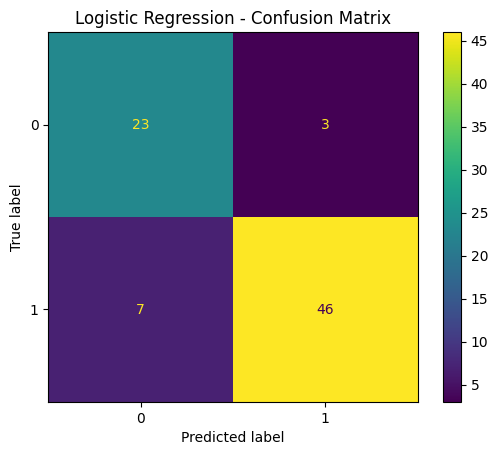

KNN Confusion Matrix:
[[25  1]
 [ 6 47]]


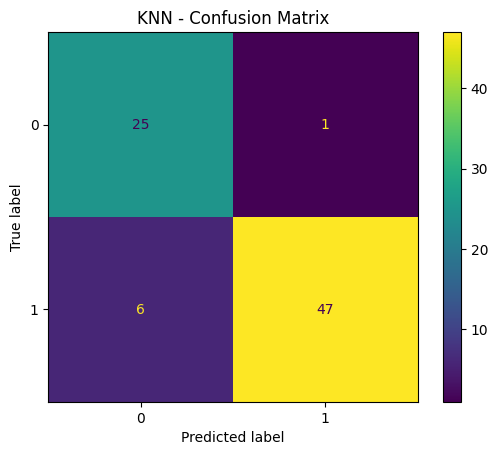

In [11]:
# Logistic Regression
cm_logistic = confusion_matrix(y_test, logistic_pred)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# KNN
cm_knn = confusion_matrix(y_test, knn_pred)

print("KNN Confusion Matrix:")
print(cm_knn)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

plt.title("KNN - Confusion Matrix")
plt.show()

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression Pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# KNN Pipeline
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])


# Logistic Regression Cross Validation
logistic_cv = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)


# KNN Cross Validation
knn_cv = cross_val_score(
    knn_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)


print("Logistic Regression CV Scores:")
print(logistic_cv)

print("Mean CV Accuracy:",
      logistic_cv.mean())


print("\nKNN CV Scores:")
print(knn_cv)

print("Mean CV Accuracy:",
      knn_cv.mean())

Logistic Regression CV Scores:
[0.93670886 0.92405063 0.84810127 0.89873418 0.92405063]
Mean CV Accuracy: 0.9063291139240507

KNN CV Scores:
[0.93670886 0.88607595 0.89873418 0.87341772 0.93670886]
Mean CV Accuracy: 0.9063291139240505


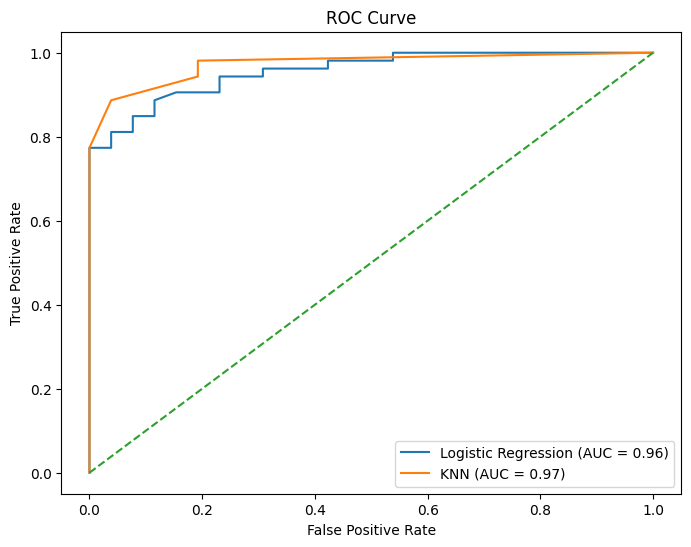

In [13]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    logistic_prob
)

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    knn_prob
)

auc_log = roc_auc_score(
    y_test,
    logistic_prob
)

auc_knn = roc_auc_score(
    y_test,
    knn_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.2f})"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN (AUC = {auc_knn:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],

    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, knn_pred)
    ],

    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, knn_pred)
    ],

    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, knn_pred)
    ],

    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, knn_pred)
    ],

    "ROC-AUC": [
        auc_log,
        auc_knn
    ],

    "CV Accuracy": [
        logistic_cv.mean(),
        knn_cv.mean()
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Accuracy
0,Logistic Regression,0.873418,0.938776,0.867925,0.901961,0.956096,0.906329
1,KNN,0.911392,0.979167,0.886792,0.930693,0.972787,0.906329
